In [3]:
import numpy as np
import os, sys 
import re
import ROOT
import pandas
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd
from scipy import signal

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [4]:
def createFilter_EvtNum():

	ROOT.gInterpreter.Declare("""
	#include <vector>
	#include <algorithm>

	bool eventFilter(const double colEventNum, const std::vector<double>& targetEventNums) {
		bool eventMatch = std::find(targetEventNums.begin(), targetEventNums.end(), colEventNum) != targetEventNums.end();
		return eventMatch;
	}
	""")

createFilter_EvtNum()

In [5]:
## R37 Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', '23240108_203134', '23231221_101235', '23231221_015705', '23231220_190923', '23231220_122140', '23231220_053358', '23231220_012745', '23231219_184002', 
             '23231219_110331', '23231219_034952', '23231218_223530', '23231218_190035', '23231218_152721', '23231218_093255', '23231218_024511', '23231217_212512', '23231217_171613', '23231217_135018', 
             '23231216_233807', '23231216_211119', '23231216_194929', '23231216_182937', '23231216_173436', '23231216_145300', '23231216_100125', '23231216_043946', '23231216_013604'][:10]
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [6]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
RQfiles_data = [x.filePath for x in dc]

In [7]:
fp = "/project/6049244/share/SimData/DMC_SNOLAB_HV/" ## this is the global file path the DMC data is saved in on compute canada

## Define the filepaths used
samples = {"L": "Ge71_Lshell_pos50V_V05-09",
           "K": "Ge71_Kshell_pos50V_V05-09"}
proc =    {"L": "/Processed/Unmerged/*/*.root",
           "K": "/Processed/Unmerged/*/*.root"}

In [8]:
## Get the file names in these folders
RQfiles_K, RQfiles_L       = np.sort(glob.glob(fp+samples["K"]+proc["K"])), np.sort(glob.glob(fp+samples["L"]+proc["L"]))

In [9]:
config_path = "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config_sim = "DMCData.HV100mm_uni_triangle"
config_data = "configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"
relcal_path = {'sim':  config_path+config_sim,
               'data': config_path+config_data}

det     = {'sim': 1, 'data': 1}
trigdet = {'sim': 0, 'data': 1}

In [10]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQ_branches = ["SeriesNumber", "EventNumber", "PTOFamps", "EventTriggerID"] + [chan + "OFamps" for chan in channels]  + [chan + "OFdelay" for chan in channels]  + [chan + "bs" for chan in channels]
DMC_branches = ["EventNum", "X", "Y", "Z"]
keVt2keVee = 1/(1 + 50/3) # inverse of Luke gain factor
lin2keVee = {'sim': 210e2 * keVt2keVee, 'data': 210e2 * keVt2keVee} # (keVt/linAmp) * (keVee / keVt)
RQs = {}

In [13]:
## load relevant RQs for simulation
df_K = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_K, friends = [[x+":rqDir/eventTree" for x in RQfiles_K]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_K_filtered = df_K.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>10.4e-6", "PTOFamps<11e-6", "EventTriggerID<300"])
RQs_K = df_K_filtered.AsNumpy(RQ_branches) # get correct ratio between L and K events. Use the fact that L shell sample has 10k events.

# deal with CDMSSIM-451
for branch in channels + ['PT']:
    RQs_K[branch + 'OFamps'] *= 10/4

# Construct and return the single dataframe with the info we care about

RQs['sim'] = RQs_K

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["sim"], 'PTOFamps', 'unbinned')
RQs["sim"]['lin_PTOFamps'] = lin_class.linearize(RQs["sim"]['PTOFamps'])
RQs["sim"]['calib_PTOFamps'] = RQs["sim"]['lin_PTOFamps'] * lin2keVee["sim"]

In [14]:
frame = pd.DataFrame(RQs['sim'])

In [15]:
chan_names = ['PAS1','PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1','PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2']

# the following is the MiCE output ROOT file that has the raw pulses 
# had to remove the following file from required_files directory because it was too large (the MiCE command is given two cells above)
filepath_raw = np.sort(glob.glob(fp+samples['K']+'/Raw/combined_MIDAS_files/5*/mice_physics_dumps/'+'*.root'))
series_list = ['51250605_000000']
targetIDs = ROOT.std.vector("double")(RQs['sim']['EventTriggerID'])
df_pulses = CDataFrame("pulses", filepath_raw).Filter(f"eventFilter(TriggerID,{targetIDs})")

# the following is just organizing all the RQs and raw events in individual dictionaries 
# to be able to filter them by event trigger IDs and series number
raw_events = {}
delay = {}
baselines = {}
events = {}
for series in series_list:
    raw_events[series] = {}
    events[series] = frame[frame["SeriesNumber"]==float(series)]["EventTriggerID"]
    # ensure the event list is not empty
    if len(events[series])>0:
        delay[series] = {}
        baselines[series] = {}
        for chan in chan_names:
            # PAS1 in det 3 is broken so skip
            if chan == 'PAS1' and det=='3': continue
            delay[series][chan] = dict(zip(events[series], frame[frame["SeriesNumber"]==float(series)][chan+"OFdelay"]))
            baselines[series][chan] = dict(zip(events[series], frame[frame["SeriesNumber"]==float(series)][chan+"bs"]))
            # extract the pulse and the triggerID from the MiCE root file and store in a dictionary as well
            pulses = df_pulses.Filters(["Series=="+str(int(series)), f"ChanName==\"{chan}\""]).AsNumpy(["Pulse", "TriggerID"])
            raw_events[series][chan] = dict(zip(pulses["TriggerID"],pulses["Pulse"]))
        print(series+' done')
    else:
        print(series+' no events')

51250605_000000 done


In [16]:
samplerate=625000
tracelength=32768

In [17]:
relcal = {
    '1': {'PFS1': 0.935,
 'PCS1': 1.002,
 'PDS1': 0.998,
 'PBS1': 1.076,
 'PES1': 1.018,
 'PAS1': 1.14,
 'PFS2': 0.895,
 'PCS2': 0.931,
 'PBS2': 1.008,
 'PES2': 0.946,
 'PDS2': 0.992,
 'PAS2': 1.059}
}

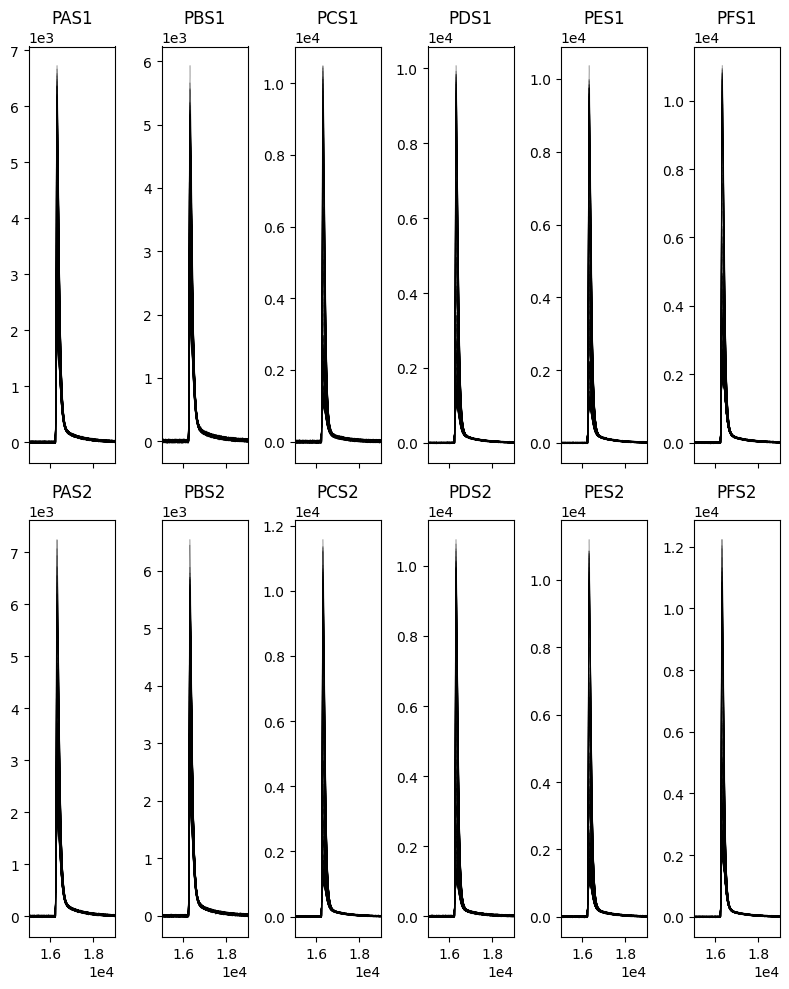

In [18]:
# a lowpass butterworth filter with a frequency cutoff at 10 kHz
sos = signal.butter(1, 10000, 'low', fs=samplerate, output='sos')
channel_set = {}
maxes = {}
fig, ax = plt.subplots(nrows=2, ncols=6, figsize=(8, 10), sharex=True)
ax = ax.flatten()

chan_names = ['PAS1', 'PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1','PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2']
for index, chan in enumerate(chan_names):
    if chan == 'PAS1' and det=='3': continue
    series_trace = {} 
    for s in series_list:
        temp = []
        numevents = events[s]
        if len(numevents)>0:
            for n in numevents:
                pulse = raw_events[s][chan][n][:]
                # subtract baseline
                trace = pulse - baselines[s][chan][n]
                # shift pulse to align the triggers
                aligned_trace = np.roll(trace, -round(delay[s][chan][n]*samplerate)) # first convert the OFdelay in secs to time bins using the sample rate
                temp.append(aligned_trace)
                # plot the filtered raw pulse 
                ax[index].plot(signal.sosfilt(sos, aligned_trace), alpha=0.3, color='black', linewidth=0.5)
            # perform an average of all pulses for a given series and normalize
            maxes[chan] = np.array([np.max(i) * relcal['1'][chan] for i in temp])
            series_trace[s] = np.mean(temp,axis=0)/np.max(np.mean(temp,axis=0))
        ax[index].set_title(chan) 
        ax[index].set_xlim(15000,19000)
        ax[index].ticklabel_format(style="sci", scilimits=(0,0))
        # store the average pulse shapes for individual series per channel
        channel_set[chan] = series_trace
        
plt.tight_layout()
plt.show()

In [19]:
Fsum = maxes['PFS1'] + maxes['PFS2']
Asum = maxes['PAS1'] + maxes['PAS2']

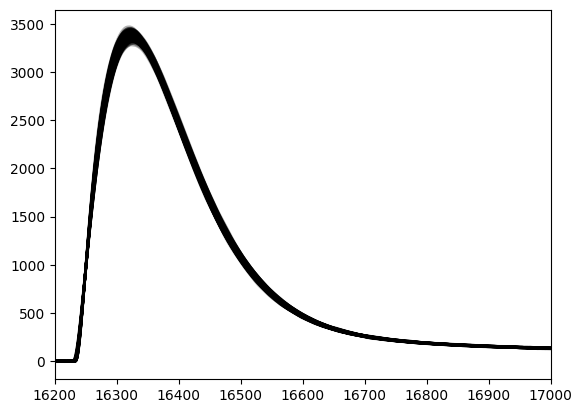

In [20]:
# PT template
# percent point at which to align the pulses and average, not using the OFdelay RQ here
p = 30          
           
sos = signal.butter(1, 10000, 'low', fs=samplerate, output='sos')
channel_set = {}
chan_names = ['PAS1', 'PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1','PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2']
for s in series_list:
    pt_trace = {}
    try:
        numevents = events[s]
    except KeyError as e:
        print('KeyError',e)
        continue
    for n in numevents:
        temp = []
        for index, chan in enumerate(chan_names):
            if chan == 'PAS1' and det=='3': continue
            # extract the pulse
            pulse = raw_events[s][chan][n][:]
            trace = (pulse - baselines[s][chan][n]) * relcal['1'][chan] # subtract baseline, then apply relative calibration factor
            #if abs(round(delay[s][chan][n]*samplerate)) > 300: continue
            aligned_trace = trace
            temp.append(aligned_trace)
        pt_event = np.mean(temp,axis=0)
        
        # PT Trace alignment
        pt_aligned = 0
        triggerindex= 16250 #Align at trigger index
        if np.any(np.isnan(pt_event)): continue
        # Apply the lowpass filter for detemining the percentage of max.
        pt_event_lp = signal.sosfilt(sos,pt_event)
        a=np.where(pt_event_lp[:np.where(pt_event_lp==max(pt_event_lp))[0][0]]< (p/100)*max(pt_event_lp))[0]
        if(len(a)!=0):
            startpulse=a[len(a)-1]
            if(startpulse>triggerindex):
                pt_aligned=np.append(pt_event[startpulse-triggerindex:],pt_event[:startpulse-triggerindex])
            else:
                pt_aligned=np.append(pt_event[len(pt_event)-triggerindex+startpulse:],pt_event[:len(pt_event)-triggerindex+startpulse])
        else:
            continue
        try:
            plt.plot(signal.sosfilt(sos,pt_aligned), alpha = 0.3, color='black')
            pt_trace[n] = pt_aligned
        except: continue
    channel_set[s] = pt_trace
plt.xlim(16200,17000)
#plt.savefig(f"plots/PTtemplates/traceOvrlay_method5_{det}.png")
plt.show()

In [21]:
maxes['PT'] = np.array([max(i) for i in list(pt_trace.values())])

In [22]:
RadialPar = (Fsum - Asum) / maxes['PT']

In [27]:
Fsum - Asum

array([ -1224.73206552,  -9729.56948728,   6587.42200401,  -2619.27603506,
        16450.42671789,   -605.93521278,   4275.51626608,  -1196.93699459,
         1836.21584833,   1142.85742116,  12197.33646604,  -4801.98940633,
        -6802.89639571,  -3953.41398878,  -6080.52357383,  -5534.78682689,
        -2828.67209217,  -6634.54897015,  -7218.78276878,  -8899.99745562,
         3423.93854258,   2409.27092947,  10258.32871388,   5998.99594931,
         2649.67496293,  -1783.15570667, -11121.44626347,   8065.68447325,
        -3698.54981907,  -3877.56519996,   1646.15109818,   3127.28576838,
        -3108.31784352,  -2692.01189221,  -9810.81562032,  -9958.38144881,
        11610.90969625,  -3348.84568363, -10104.02901362,  -4417.26486416,
        -5497.94512743,  -4011.21668543,   7491.38185013,   1040.266668  ,
         3192.40196053,  -5385.28356201,  -2772.15526007,  -2656.73762272,
        -7032.2201693 ,    636.78854378,  -6012.1821104 ,  -9711.8233356 ,
        -4248.35358826,  

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


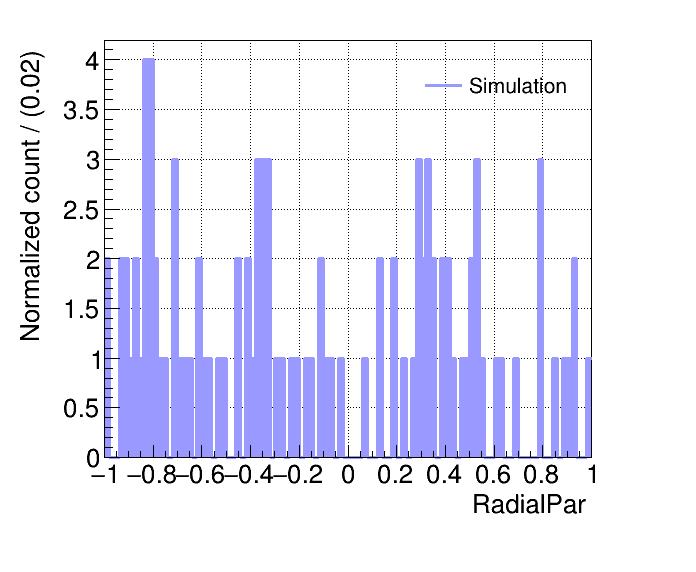

In [28]:
bins_start, bins_end, nbins = -1, 1, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

hist.createHist(RadialPar, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation")

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()